In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("athlete_events.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
df


(271116, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB
None
ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year    

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [3]:
athlete_count = df.groupby(['Year', 'NOC'])['ID'].nunique().reset_index()
athlete_count.rename(columns={'ID': 'Athlete_Count'}, inplace=True)
df = df.merge(athlete_count, on=['Year', 'NOC'], how='left')

event_count = df.groupby(['Year', 'NOC'])['Event'].nunique().reset_index()
event_count.rename(columns={'Event': 'Event_Count'}, inplace=True)
df = df.merge(event_count, on=['Year', 'NOC'], how='left')
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,Athlete_Count,Event_Count
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,276,176
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,375,206
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,154,66
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,13,14
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,158,96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269726,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,263,141
269727,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,58,58
269728,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,58,58
269729,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,39,35


In [4]:
df['Medal_Value'] = df['Medal'].map({
    'Gold': 3,
    'Silver': 2,
    'Bronze': 1
})
df['total_medals'] = df['Medal_Value'].fillna(0)
medal_count = df[df['Medal'].notna()] \
    .groupby(['Year', 'NOC'])['Medal'] \
    .count() \
    .reset_index()

df.drop(columns=[ 'Name', 'Games'], inplace=True)

In [5]:
df = df.sort_values(by=['Year', 'NOC']).reset_index(drop=True)

df

,ID,Sex,Age,Height,Weight,Team,NOC,Year,Season,City,Sport,Event,Medal,Athlete_Count,Event_Count,Medal_Value,total_medals
0,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Tennis,Tennis Men's Singles,NaN,1,5,NaN,0.0
1,35698,M,22.0,NaN,NaN,Australia/Great Britain,AUS,1896,Summer,Athina,Tennis,Tennis Men's Doubles,Bronze,1,5,1.0,1.0
2,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Athletics,Athletics Men's 800 metres,Gold,1,5,3.0,3.0
3,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Athletics,"Athletics Men's 1,500 metres",Gold,1,5,3.0,3.0
4,35698,M,22.0,NaN,NaN,Australia,AUS,1896,Summer,Athina,Athletics,Athletics Men's Marathon,NaN,1,5,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269726,87478,F,29.0,158.0,57.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Football,Football Women's Football,NaN,30,13,NaN,0.0
269727,92718,M,27.0,191.0,87.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Rowing,Rowing Men's Single Sculls,NaN,30,13,NaN,0.0
269728,116713,M,37.0,186.0,78.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Archery,Archery Men's Individual,NaN,30,13,NaN,0.0
269729,120082,F,29.0,175.0,72.0,Zimbabwe,ZIM,2016,Summer,Rio de Janeiro,Rowing,Rowing Women's Single Sculls,NaN,30,13,NaN,0.0


In [6]:
final_df = df.groupby(['Year', 'NOC']).agg({
    'ID': 'nunique',         
    'Event': 'nunique',       
    'Medal_Value': 'sum',     
    'Medal': lambda x: x.notna().sum()   
}).reset_index()
final_df.rename(columns={
    'ID': 'Athlete_Count',
    'Event': 'Event_Count',
    'Medal_Value': 'Medal_Points',
    'Medal': 'Total_Medals'
}, inplace=True)
final_df = final_df.sort_values(by=['Year', 'NOC']).reset_index(drop=True)
final_df['Prev_Medals'] = final_df.groupby('NOC')['Total_Medals'].shift(1)
final_df['Prev_Medals'] = final_df['Prev_Medals'].fillna(0)
final_df

,Year,NOC,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals
0,1896,AUS,1,5,7.0,3,0.0
1,1896,AUT,3,8,10.0,5,0.0
2,1896,DEN,3,12,10.0,6,0.0
3,1896,FRA,12,18,25.0,11,0.0
4,1896,GBR,10,19,18.0,9,0.0
...,...,...,...,...,...,...,...
3300,2016,VIE,22,24,5.0,2,0.0
3301,2016,VIN,4,4,0.0,0,0.0
3302,2016,YEM,3,3,0.0,0,0.0
3303,2016,ZAM,7,7,0.0,0,0.0


In [7]:
final_df['Medal_Rolling_Avg'] = final_df.groupby('NOC')['Total_Medals'] \
    .rolling(3).mean().reset_index(0, drop=True)
final_df['Medal_Rolling_Avg'] = final_df['Medal_Rolling_Avg'].fillna(0)
final_df

,Year,NOC,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals,Medal_Rolling_Avg
0,1896,AUS,1,5,7.0,3,0.0,0.0
1,1896,AUT,3,8,10.0,5,0.0,0.0
2,1896,DEN,3,12,10.0,6,0.0,0.0
3,1896,FRA,12,18,25.0,11,0.0,0.0
4,1896,GBR,10,19,18.0,9,0.0,0.0
...,...,...,...,...,...,...,...,...
3300,2016,VIE,22,24,5.0,2,0.0,1.0
3301,2016,VIN,4,4,0.0,0,0.0,0.0
3302,2016,YEM,3,3,0.0,0,0.0,0.0
3303,2016,ZAM,7,7,0.0,0,0.0,0.0


In [8]:
final_df[final_df['NOC'] == 'USA']

,Year,NOC,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals,Medal_Rolling_Avg
11,1896,USA,14,16,49.0,20,0.0,0.000000
42,1900,USA,75,41,139.0,63,20.0,0.000000
57,1904,USA,524,95,791.0,394,63.0,159.000000
78,1906,USA,38,28,54.0,24,394.0,160.333333
100,1908,USA,122,52,149.0,65,24.0,161.000000
129,1912,USA,174,68,224.0,107,65.0,65.333333
157,1920,USA,288,113,461.0,194,107.0,122.000000
203,1924,USA,323,119,436.0,194,194.0,165.000000
248,1928,USA,304,108,238.0,102,194.0,163.333333
295,1932,USA,538,136,473.0,223,102.0,173.000000


In [9]:
df = pd.get_dummies(final_df, columns=['NOC'])
df

,Year,Athlete_Count,Event_Count,Medal_Points,Total_Medals,Prev_Medals,Medal_Rolling_Avg,NOC_AFG,NOC_AHO,NOC_ALB,...,NOC_VIE,NOC_VIN,NOC_VNM,NOC_WIF,NOC_YAR,NOC_YEM,NOC_YMD,NOC_YUG,NOC_ZAM,NOC_ZIM
0,1896,1,5,7.0,3,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1896,3,8,10.0,5,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1896,3,12,10.0,6,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1896,12,18,25.0,11,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1896,10,19,18.0,9,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3300,2016,22,24,5.0,2,0.0,1.0,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3301,2016,4,4,0.0,0,0.0,0.0,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3302,2016,3,3,0.0,0,0.0,0.0,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3303,2016,7,7,0.0,0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False


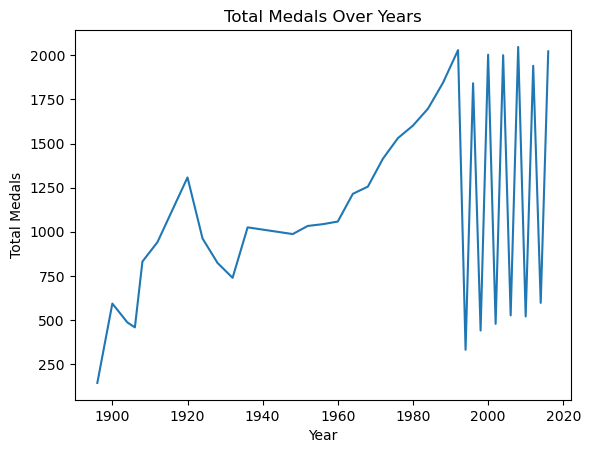

In [10]:
yearly_medals = final_df.groupby('Year')['Total_Medals'].sum()

plt.plot(yearly_medals)
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.title("Total Medals Over Years")
plt.show()

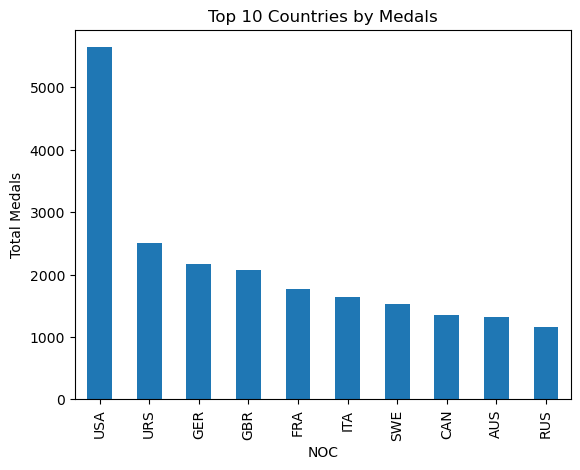

In [11]:
top_countries = final_df.groupby('NOC')['Total_Medals'].sum().sort_values(ascending=False).head(10)

top_countries.plot(kind='bar')
plt.title("Top 10 Countries by Medals")
plt.ylabel("Total Medals")
plt.show()

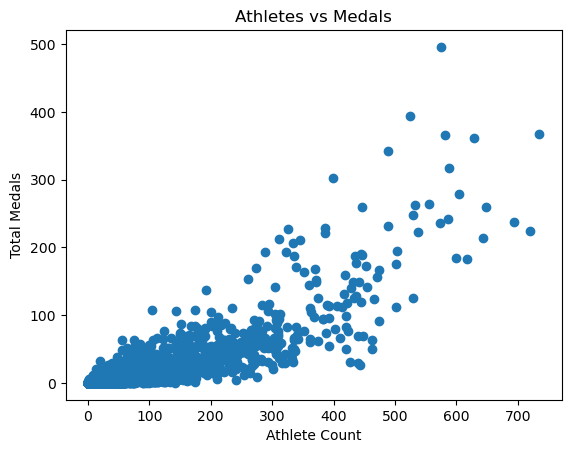

In [12]:
plt.scatter(final_df['Athlete_Count'], final_df['Total_Medals'])
plt.xlabel("Athlete Count")
plt.ylabel("Total Medals")
plt.title("Athletes vs Medals")
plt.show()

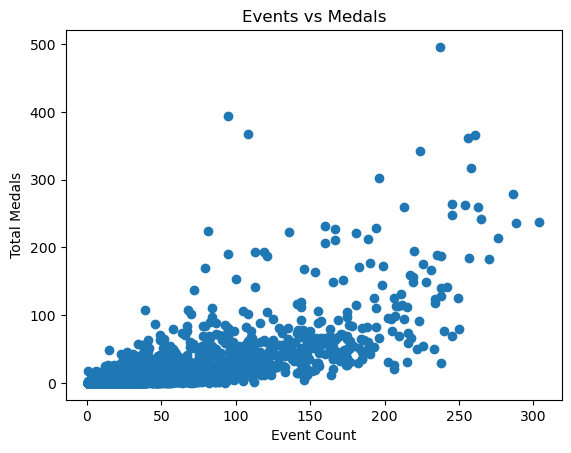

In [13]:
plt.scatter(final_df['Event_Count'], final_df['Total_Medals'])
plt.xlabel("Event Count")
plt.ylabel("Total Medals")
plt.title("Events vs Medals")
plt.show()

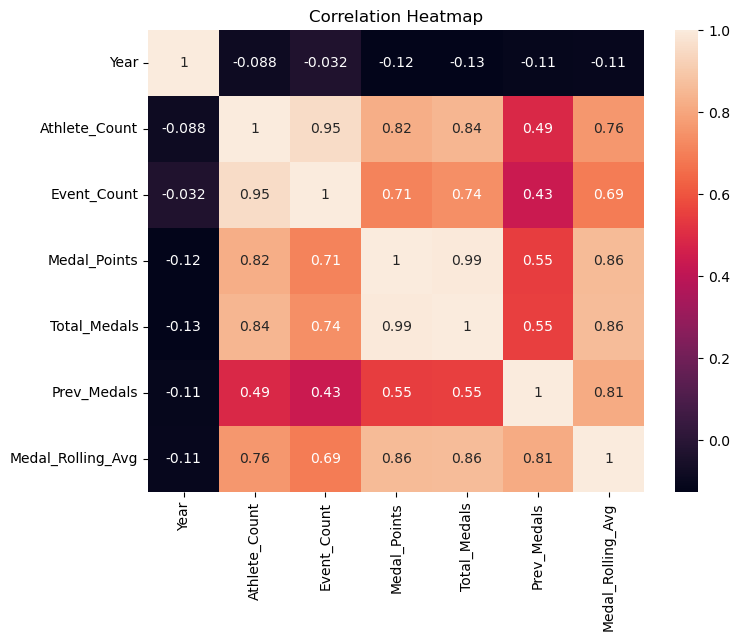

In [14]:
numeric_df = final_df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

/var/folders/nr/40b30qld2473f5h59rq9tnm80000gn/T/ipykernel_23153/4004013750.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Correlation', y='Feature', data=corr_df, palette='coolwarm',orient="h")


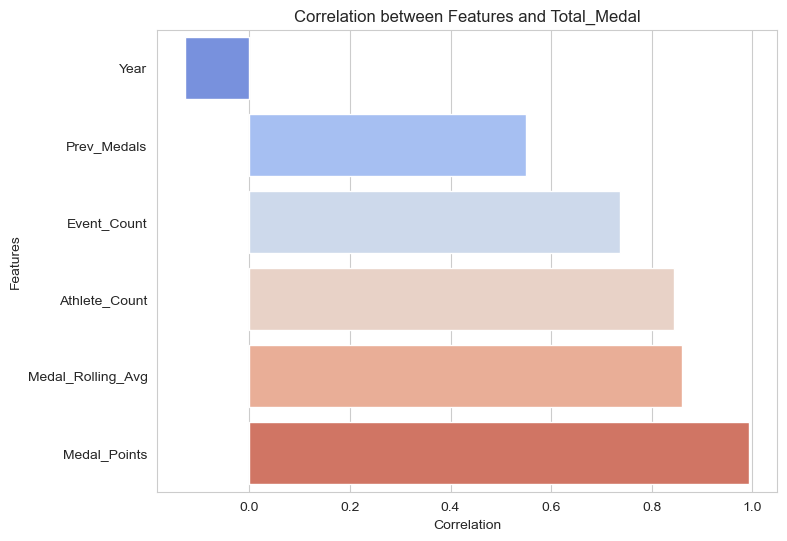

In [15]:
numeric_df = final_df.select_dtypes(include=['number'])
corr = numeric_df.corr()['Total_Medals'].drop('Total_Medals').sort_values()
corr_df = corr.reset_index()
corr_df.columns = ['Feature', 'Correlation']
sns.set_style("whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(x='Correlation', y='Feature', data=corr_df, palette='coolwarm',orient="h")

plt.title("Correlation between Features and Total_Medal")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

In [16]:
""" Backward Selection
X = df.drop(columns=['Total_Medals', 'Medal_Points'])
y = df['Total_Medals']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()

sfs_backward = SequentialFeatureSelector(
    model,
    n_features_to_select=10,     
    direction='backward',        
    scoring='r2',
    cv=3,
    n_jobs=-1
)

sfs_backward.fit(X_train, y_train)


selected_features = X_train.columns[sfs_backward.get_support()]
print("Selected Features:", selected_features)


model.fit(X_train[selected_features], y_train)

y_pred = model.predict(X_test[selected_features])


print("\n--- Backward Selection Model ---")
print("Train R2:", r2_score(y_train, model.predict(X_train[selected_features])))
print("Test R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

"""

#Forward selection
X = df.drop(columns=['Total_Medals', 'Medal_Points'])
y = df['Total_Medals']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


model = LinearRegression()

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=10,  
    direction='forward',
    scoring='r2',             
    cv=5,
    n_jobs=-1
)

sfs.fit(X_train, y_train) 

,estimator estimator: estimator instanceAn unfitted estimator.,LinearRegression()
,"n_features_to_select n_features_to_select: ""auto"", int or float, default=""auto""If `""auto""`, the behaviour depends on the `tol` parameter:- if `tol` is not `None`, then features are selected while the score change does not exceed `tol`.- otherwise, half of the features are selected.If integer, the parameter is the absolute number of features to select.If float between 0 and 1, it is the fraction of features to select... versionadded:: 1.1 The option `""auto""` was added in version 1.1... versionchanged:: 1.3 The default changed from `""warn""` to `""auto""` in 1.3.",10
,"tol tol: float, default=NoneIf the score is not incremented by at least `tol` between twoconsecutive feature additions or removals, stop adding or removing.`tol` can be negative when removing features using `direction=""backward""`.`tol` is required to be strictly positive when doing forward selection.It can be useful to reduce the number of features at the cost of a smalldecrease in the score.`tol` is enabled only when `n_features_to_select` is `""auto""`... versionadded:: 1.1",None
,"direction direction: {'forward', 'backward'}, default='forward'Whether to perform forward selection or backward selection.",'forward'
,"scoring scoring: str or callable, default=NoneScoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)`` that returns a single value. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. In all othercases, :class:`~sklearn.model_selection.KFold` is used. These splittersare instantiated with `shuffle=False` so the splits will be the sameacross calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel. When evaluating a new feature toadd or remove, the cross-validation procedure is parallel over thefolds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [17]:
selected_features = X_train.columns[sfs.get_support()]

print("Selected Features:")
print(selected_features)

Selected Features:
Index(['Year', 'Athlete_Count', 'Event_Count', 'Prev_Medals',
       'Medal_Rolling_Avg', 'NOC_AUT', 'NOC_BRA', 'NOC_CAN', 'NOC_ESP',
       'NOC_ITA'],
      dtype='object')


In [18]:
model.fit(X_train[selected_features], y_train)

y_pred = model.predict(X_test[selected_features])

from sklearn.metrics import r2_score, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.8325887140021297
MSE: 214.1605582558945


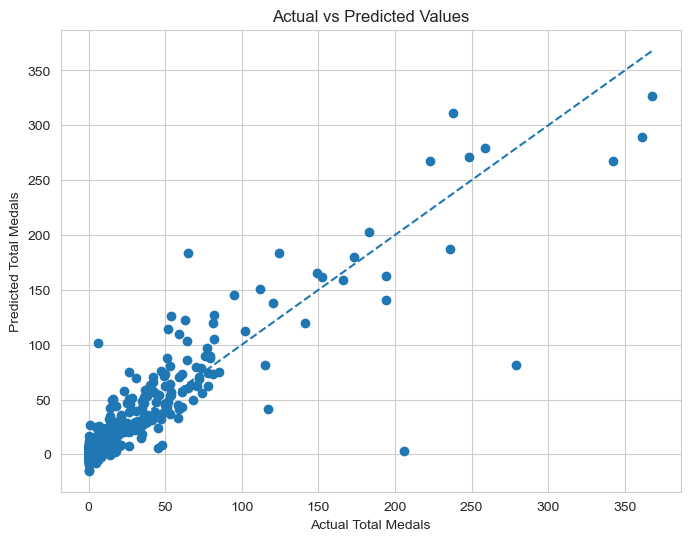

In [19]:


plt.figure(figsize=(8,6))


plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Total Medals")
plt.ylabel("Predicted Total Medals")
plt.title("Actual vs Predicted Values")

plt.show()

In [20]:
print("Train R2:", r2_score(y_train, model.predict(X_train[selected_features])))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.9024919743455444
Test R2: 0.8325887140021297


In [22]:
#Random Forest 

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error



X = df.drop(columns=['Total_Medals', 'Medal_Points'])
y = final_df['Total_Medals']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


rf_model = RandomForestRegressor(
    n_estimators=200,        # number of trees
    max_depth=None,          # let trees grow fully
    random_state=42,
    n_jobs=-1                # use all cores
)


rf_model.fit(X_train, y_train)

y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("RMSE:", rmse)
print("===== Random Forest Results =====")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2 :", r2_score(y_test, y_pred_test))
print("RMSE    :", rmse)

RMSE: 12.14498690183272
===== Random Forest Results =====
Train R2: 0.9865112142610336
Test R2 : 0.8868615578388626
RMSE    : 12.14498690183272


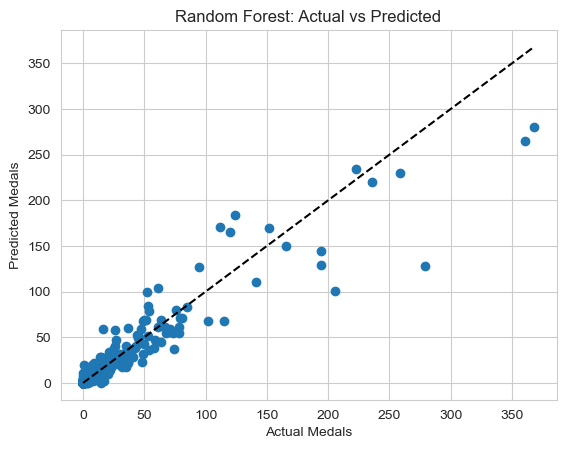

In [24]:
plt.scatter(y_test, y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.xlabel("Actual Medals")
plt.ylabel("Predicted Medals")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [27]:
#Support vector regressor

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error


X = df.drop(columns=['Total_Medals', 'Medal_Points'])
y = final_df['Total_Medals']


from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=100, gamma=0.1))
])

svr_model.fit(X_train, y_train)

y_pred_train = svr_model.predict(X_train)
y_pred_test = svr_model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("===== SVR Results =====")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2 :", r2_score(y_test, y_pred_test))
print("RMSE    :", rmse)

===== SVR Results =====
Train R2: 0.8611393295182846
Test R2 : 0.6127629437715731
RMSE    : 22.46882741955582


In [28]:
# KNN REGRESSION

from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))
])


knn_model.fit(X_train, y_train)

y_pred_train = knn_model.predict(X_train)
y_pred_test = knn_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("===== KNN Results =====")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2 :", r2_score(y_test, y_pred_test))
print("RMSE    :", rmse)

===== KNN Results =====
Train R2: 0.8569936086348071
Test R2 : 0.7499242028347306
RMSE    : 18.05625936536383


In [29]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 6.6 MB/s eta 0:00:00a 0:00:01


In [30]:
#Xg boost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)


y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("===== XGBoost Results =====")
print("Train R2:", r2_score(y_train, y_pred_train))
print("Test R2 :", r2_score(y_test, y_pred_test))
print("RMSE    :", rmse)

===== XGBoost Results =====
Train R2: 0.9952001571655273
Test R2 : 0.8954824805259705
RMSE    : 11.673108384255924


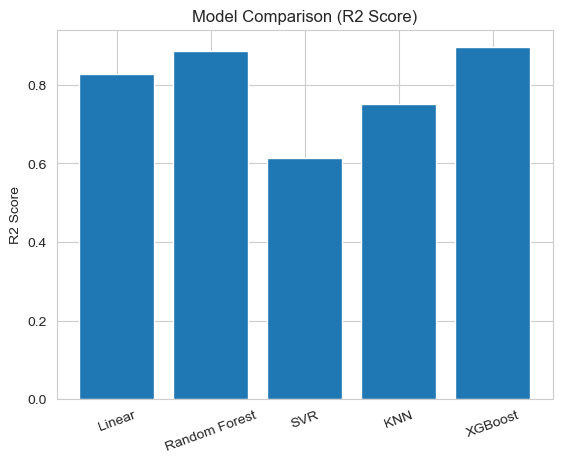

In [36]:
models = ['Linear', 'Random Forest', 'SVR', 'KNN', 'XGBoost']

r2_scores = [
    r2_score(y_test, model.predict(X_test[selected_features])),   
    r2_score(y_test, rf_model.predict(X_test)),
    r2_score(y_test, svr_model.predict(X_test)),
    r2_score(y_test, knn_model.predict(X_test)),
    r2_score(y_test, xgb_model.predict(X_test))
]
import matplotlib.pyplot as plt

plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

In [44]:
import pandas as pd

def predict_medals_simple(country_code, year):
    

    country_data = df[df['NOC_' + country_code] == True].sort_values('Year')
    
    if country_data.empty:
        print("No data found for this country")
        return None
    
   
    last_row = country_data.iloc[-1]
    
   
    athlete_count = last_row['Athlete_Count']
    event_count = last_row['Event_Count']
    prev_medals = last_row['Total_Medals']
    rolling_avg = last_row['Medal_Rolling_Avg']
    
    if pd.isna(rolling_avg):
        rolling_avg = prev_medals
    

    input_data = pd.DataFrame(columns=selected_features)
    input_data.loc[0] = 0
    
   
    if 'Year' in selected_features:
        input_data['Year'] = year
        
    if 'Athlete_Count' in selected_features:
        input_data['Athlete_Count'] = athlete_count
        
    if 'Event_Count' in selected_features:
        input_data['Event_Count'] = event_count
        
    if 'Prev_Medals' in selected_features:
        input_data['Prev_Medals'] = prev_medals
        
    if 'Medal_Rolling_Avg' in selected_features:
        input_data['Medal_Rolling_Avg'] = rolling_avg
    

    noc_col = f"NOC_{country_code}"
    if noc_col in selected_features:
        input_data[noc_col] = 1
    
   
    prediction = model.predict(input_data)[0]
    
    return int(prediction)

In [50]:
noc= input(str("Enter the NOC of the country"))
year=int(input("Which Year's Performance you want to predict"))

pred = predict_medals_simple(noc,year)
print("Predicted medals:", pred)

Enter the NOC of the country USA
Which Year's Performance you want to predict 1998


Predicted medals: 188
